# Programa de ciencias de datos

Mi primer ML
Pamela Cerdas

1. Acceso a los datos

In [ ]:
# Librerias basicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
datatrain = pd.read_csv("/content/sample_data/california_housing_test.csv")
datatrain.sample()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
902,-122.3,38.29,20.0,1789.0,434.0,1113.0,398.0,2.4728,139700.0


In [ ]:
datatest = pd.read_csv("/content/sample_data/california_housing_train.csv")
datatest.sample()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
13790,-122.01,37.39,26.0,2500.0,962.0,2374.0,879.0,3.5586,222200.0


In [ ]:
print("Tamaño de datos entrenamiento", datatrain.shape)
print("Tamaño de datos prueba", datatest.shape)

Tamaño de datos entrenamiento (3000, 9)
Tamaño de datos prueba (17000, 9)


## 2. Conjunto de Entrenamiento, Validación y prueba & Validació - Cruzada

- En cualquier problema ML lo recomendable es trabajar con una triple partición del universo de datos: Entrenamiento, validacion y prueba.

Validacion cruzada

##3. Transformaciones durante el preprocesamiento

**Pipeline:** Tubería, facilita y automatiza el proceso de limpiado y preparación de los datos.

*   Transformacion de distribucion
*   Normalizacion o estandarizacion



In [ ]:
datatrain.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB


In [ ]:
sns.set(rc={'figure.figsize':(10,12)})

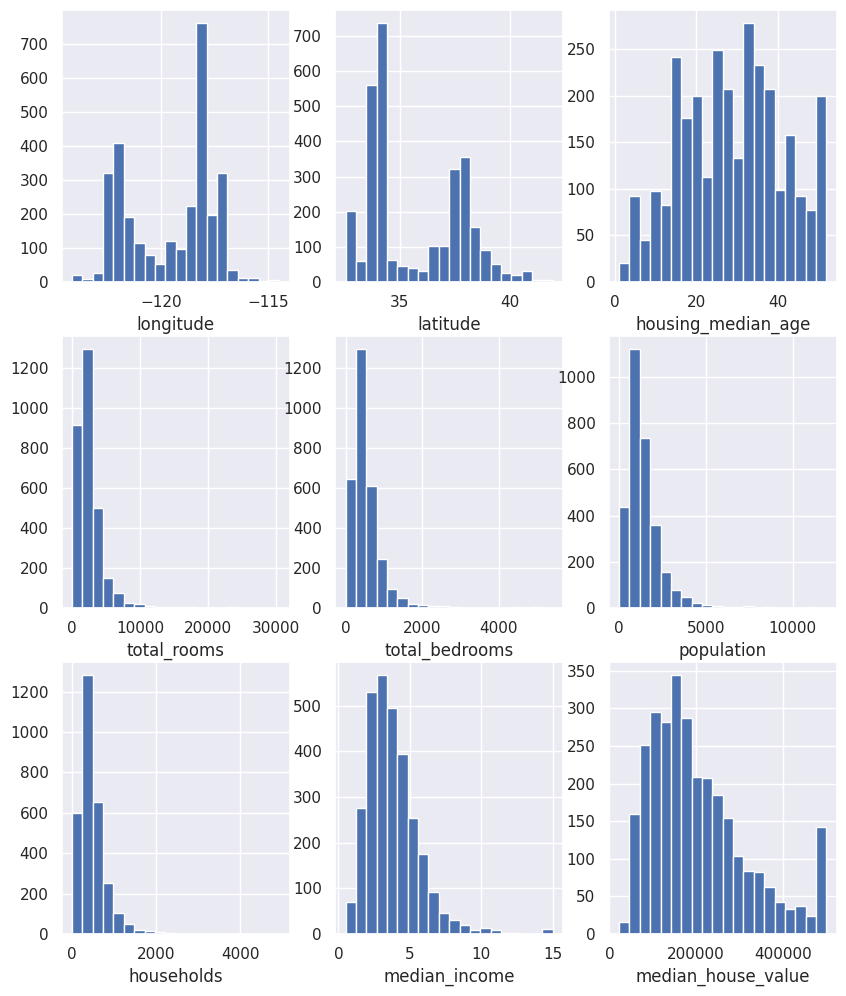

In [ ]:
fig, axes = plt.subplots(3, 3)    # Definimos una ventana de 3x3 nichos para incluir en cada uno de ellos un gráfico.
for k in range(0,9):
  plt.subplot(3,3,k+1)     # Los nichos para cada histograma se numeran iniciando en 1.
  plt.hist(datatrain[datatrain.columns[k]], bins=20)     # datatrain.columns nos devuelve una lista con los nombres de las columnas.
  plt.xlabel(datatrain.columns[k])
plt.show()

In [ ]:
datatrain.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000
mean,-119.589200,35.63539,28.845333,2599.578667,529.950667,1402.798667,489.91200,3.807272,205846.27500
std,1.994936,2.12967,12.555396,2155.593332,415.654368,1030.543012,365.42271,1.854512,113119.68747
min,-124.180000,32.56000,1.000000,6.000000,2.000000,5.000000,2.00000,0.499900,22500.00000
25%,-121.810000,33.93000,18.000000,1401.000000,291.000000,780.000000,273.00000,2.544000,121200.00000
50%,-118.485000,34.27000,29.000000,2106.000000,437.000000,1155.000000,409.50000,3.487150,177650.00000
75%,-118.020000,37.69000,37.000000,3129.000000,636.000000,1742.750000,597.25000,4.656475,263975.00000
max,-114.490000,41.92000,52.000000,30450.000000,5419.000000,11935.000000,4930.00000,15.000100,500001.00000


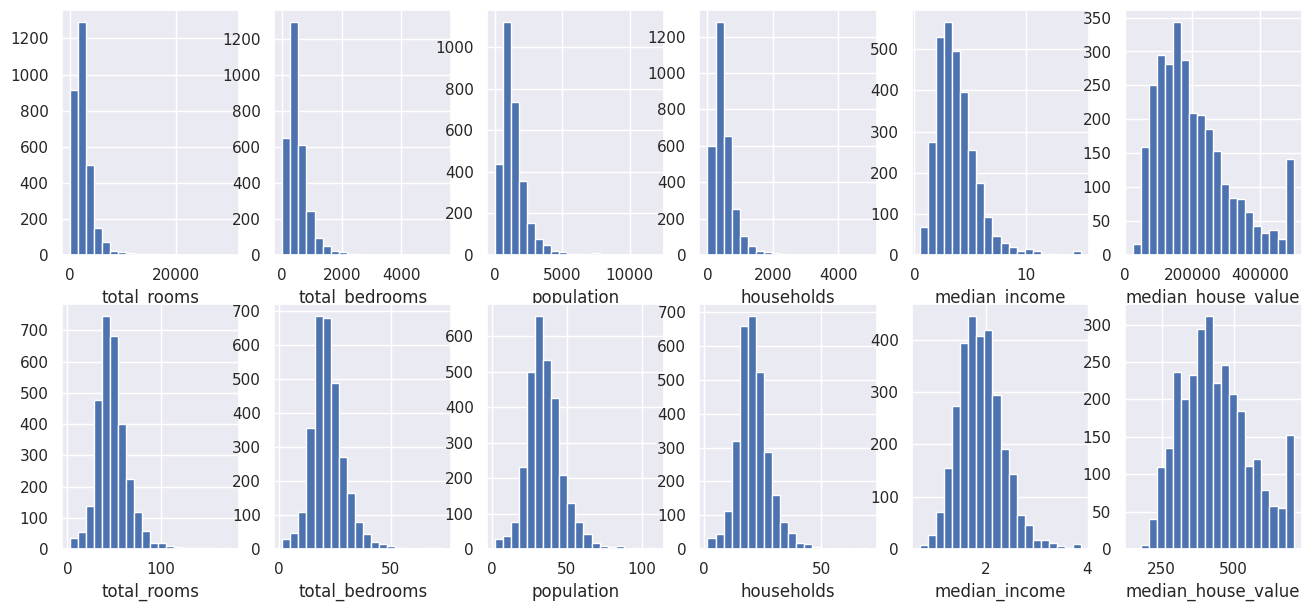

In [ ]:
sns.set(rc={'figure.figsize':(16,7)})

fig, axes = plt.subplots(2, 6)
for k in range(3,9):             # grafiquemos por el momento solo los factores con marcado sesgo positivo.
  plt.subplot(2,6,k-2)

  tmp = datatrain[datatrain.columns[k]]   # datos originales.
  plt.hist(tmp, bins=20)
  plt.xlabel(datatrain.columns[k])

  plt.subplot(2,6,k+4)
  tmp = np.sqrt(datatrain[datatrain.columns[k]])   # datos con alguna transformación para ajuste de la distribución.
  plt.hist(tmp, bins=20)
  plt.xlabel(datatrain.columns[k])

plt.show()

## 4. Métricas de desempeño

RMSE (Root Mean Square Error)
y= valor real
y ^= Valor predicho po el modelo
n= número de observac1iones


In [ ]:
# Definimos nuestra función del coeficiente de determinación ajustado a partir de las fórmulas dadas anteriormente, donde:
#    y_true: valores observados reales
#    y_hat : predicciones

# Suma de cuadrados de los errores:
def mi_SSE(y_true, y_hat):
  return sum( np.square(y_true - y_hat))

# Suma de cuadrados de la variabilidad total:
def mi_Syy(y_true, ymtrain):    # observa que se usa el valor promedio de las observaciones del conjunto de entrenamiento ymtrain.
  return sum( np.square(y_true - ymtrain))

# Coeficiente de determinación ajustado:
def mi_R2adj(sse, syy, n, k):
  tmp = ((n-1) / (n-k-1)) * (sse/syy)     # n:total de registros. k: total de variables independientes (predictores).
  return 1 - tmp    # coeficiente de determinación ajustado R2adj

## 5. Conjuntando todos los pasos para el entrenamiento del modelo RLM

In [ ]:
# Librerias
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold #Particicones de cv

In [ ]:
# con los dstos de entrenamiento
# se generan las particiones de cv:
Xtrain = datatrain.drop('median_house_value', axis='columns')
ytrain = datatrain['median_house_value']

# Dividir los datos de prueba
Xtest = datatest.drop('median_house_value', axis='columns')
ytest = datatest['median_house_value']

**Preprocesamiento** ⌛

In [ ]:
num_prepro_pipeline = Pipeline (steps= [ ('imputar', SimpleImputer(strategy='median')),
    ('escalar', MinMaxScaler(feature_range=(1,2)))]) # escalamiento
num_prepro_nombre = list(Xtrain.columns)



# Transformar raiz cuadrada para las variables con sesgos
num_raiz_pipeline = Pipeline(steps= [('sqrt', FunctionTransformer(np.sqrt))]) #Transformacion
num_raiz_nombre = ['total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
# Aplicamos las transformaciones a las variables indicadas
columnasTransformer = ColumnTransformer(transformers=[('num_prepro', num_prepro_pipeline, num_prepro_nombre),
                                ('num_raiz', num_raiz_pipeline, num_raiz_nombre)], remainder= 'passthrough')

In [ ]:
# Seleccionamos nuestro modelo de ML, en nuestro caso RLM:
modelo_LR = LinearRegression()

# Calculo de metricas de desempeño
scoresR2train = []
scoresR2Val = []
scoresmiR2Val = []
scoresmiR2adjVal = []
socresRMSEVal = []

# Inicializamos la CV usando KFOLD con K = 5
k = 5
Kf = KFold(n_splits=k, shuffle=True)

/tmp/ipykernel_1224/482199972.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=names, showmeans=True, vert=False)


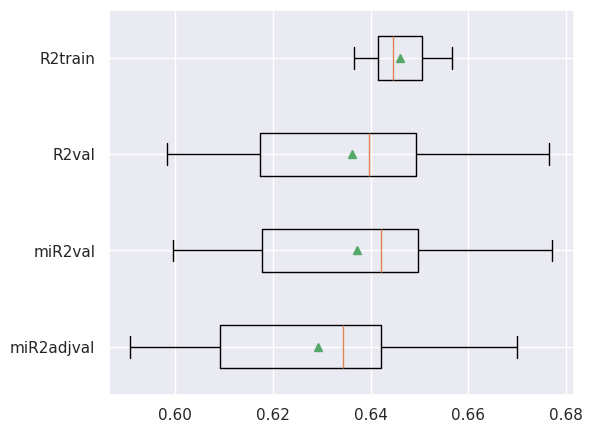

In [ ]:
# Aplicamos Cv mediante la evaluacion de cada una de las particiones:
for train_index, val_index in Kf.split(Xtrain):
    # En cada particion definimos ahora si el conjunto de entrenamiento y el de validacion:
    x_train, x_val = Xtrain.loc[train_index], Xtrain.loc[val_index]
    y_train, y_val = ytrain[train_index], ytrain[val_index]

    # Aplicamos las transformaciones al conjunto de entrenamiento:
    # Fit and transform the preprocessor on the training fold, then transform the validation fold
    X_train_transformed = columnasTransformer.fit_transform(x_train)
    X_val_transformed = columnasTransformer.transform(x_val)
    ymtrain = y_train.mean() # Promedio de las observaciones del conjunto de entrenamiento, no va a servir para calcular SYY

    # Generemos el modelo de regresion lineal con los datos de entrenamiento de cada particion:
    modelo_LR.fit(X_train_transformed, y_train)
    scoresR2train.append(modelo_LR.score(X_train_transformed, y_train))
    yhat = modelo_LR.predict(X_val_transformed) # Predicciones del conjunto de validacion
    scoresR2Val.append(modelo_LR.score(X_val_transformed, y_val)) # guardamos los valores para calcular el r2 del conjunto de validacion

    # Calcularemos el valor de r2 con nuestras formaulas. con una pequeña filtracion
    sse = mi_SSE(y_val, yhat)
    syy = mi_Syy(y_val, ymtrain)
    scoresmiR2Val.append(1-sse/syy) # Appending R2 from custom formula to the unadjusted R2 list

    #R ajustado
    tmp = mi_R2adj(sse, syy, X_val_transformed.shape[0], X_val_transformed.shape[1])
    scoresmiR2adjVal.append(tmp)

    # RMSE
    ss = np.sqrt(mean_squared_error(y_val, yhat))
    socresRMSEVal.append(ss)



    # Mostremos los diagramas de caja de los resultados obtenidos:
results = [scoresmiR2adjVal,scoresmiR2Val,scoresR2Val,scoresR2train]
names = ['miR2adjval','miR2val','R2val','R2train']

sns.set(rc={'figure.figsize':(6,5)})
plt.boxplot(results, labels=names, showmeans=True, vert=False)
plt.show()

In [ ]:
# Despleguemos los resultados de los diferentes coeficientes de determinación obtenidos:

print("\t  %s \t%s   \t%s \t%s" % (names[3],names[2],names[1],names[0]))

for i,z in enumerate(zip(scoresR2train, scoresR2Val, scoresmiR2Val, scoresmiR2adjVal)):
  print("fold[%d]:  %.4f \t%.4f  \t%.4f  \t%.4f" % (i+1,z[0],z[1],z[2],z[3]))

print("mean(std) %.3f(%.3f)  %.3f(%.3f)    %.3f(%.3f)    %.3f(%.3f)" % (np.mean(scoresR2train), np.std(scoresR2train),
                                                                        np.mean(scoresR2Val), np.std(scoresR2Val),
                                                                        np.mean(scoresmiR2Val), np.std(scoresmiR2Val),
                                                                        np.mean(scoresmiR2adjVal), np.std(scoresmiR2adjVal)))

	  R2train 	R2val   	miR2val 	miR2adjval
fold[1]:  0.6365 	0.6766  	0.6772  	0.6701
fold[2]:  0.6445 	0.6397  	0.6422  	0.6343
fold[3]:  0.6566 	0.5982  	0.5995  	0.5906
fold[4]:  0.6506 	0.6173  	0.6177  	0.6092
fold[5]:  0.6415 	0.6493  	0.6498  	0.6420
mean(std) 0.646(0.007)  0.636(0.027)    0.637(0.027)    0.629(0.027)


In [ ]:
# Y ahora despleguemos los valores de RMSE de validación de cada partición:

print("\t  RMSEval")

for i,s in enumerate(socresRMSEVal):
  print("fold[%d]:  %.2f" % (i+1,s))

#print("\t %.2f (%.2f)" % (np.mean(scoresMSEVal), np.std(scoresMSEVal)))
print("mean(std) %.2f (%.2f)" % (np.mean(socresRMSEVal), np.std(socresRMSEVal)))

	  RMSEval
fold[1]:  63392.81
fold[2]:  68207.49
fold[3]:  75407.49
fold[4]:  66454.25
fold[5]:  67019.16
mean(std) 68096.24 (3986.11)


## 6. Modelo final, conjunto test y conclusiones

In [ ]:
# Inicializamos de nuevo nuestro mejor modelo con sus parámetros predeterminados:
modelo_LRf = LinearRegression()
# Ajustamos las transformaciones con el conjunto de "entrenamiento aumentado", i.e., el train-set
# completo del archivo inicial, pero con los MISMOS PASOS que ya se decidieron en la etapa de entrenamiento previa:
XtrainTf = columnasTransformer.fit(Xtrain)
XtrainFTf = XtrainTf.transform(Xtrain)   # Aplicamos las mejores transformaciones  a los datos completos de train.
XtestFTf = XtrainTf.transform(Xtest)     # Aplicamos las transformaciones a Test con la información de Train para evitar la filtración.
                                         # Observa que esta es la primera vez que usamos los datos de prueba (Test) desde que iniciamos.
modelo_LRf = modelo_LRf.fit(XtrainFTf, ytrain)   # Entrenamos el mejor modelo con el conjunto de "entrenamiento aumentado".
yhatf = modelo_LRf.predict(XtestFTf)    # Generamos las predicciones con los datos de prueba (Test).
ymtrainf = np.mean(ytrain)     # Obtenemos el promedio de los datos de entrenamiento (recuerda que sklearn no nos regresa R2adj).
ssef = mi_SSE(ytest, yhatf)
syyf = mi_Syy(ytest, ymtrainf)
miR2adjf = mi_R2adj(ssef,syyf,XtestFTf.shape[0],XtestFTf.shape[1])   # Obtenemos R2adj con nuestra función que definimos previamente.
print("Métricas de desempeño del modelo final obtenido con el conjunto de prueba:")
print("Coeficiente de determinación ajustado: miR2adj = %.4f" % miR2adjf)
#print("Coeficiente de determinación R2 con filtración: %.4f" % modelo_LRf.score(XtestFTf, ytest))
RMSEtestf = np.sqrt(mean_squared_error(ytest, yhatf))
print("Raíz del error cuadrático medio: RMSE = %.2f" % RMSEtestf)

NameError: name 'Xtest' is not defined